# Does hosting the Olympics make the home team's stock market win gold? 🏅📉
### National pride, an infrastructure boom, tourism — a great story. Does the tape agree?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth-check: Busted](https://img.shields.io/badge/Myth--check-BUSTED-8b949e?style=flat-square)

Every host-city bid is sold partly on this promise: the Games will put us on the map, build our infrastructure, fill our hotels — and, the folklore adds, light up our stock market. It's a fun story with a clean mechanism. We tested it on the six Summer Olympics hosts (2000→2024) that had a country you could actually buy a share of.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the power math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Only **six** hosts have a contemporaneous single-country ETF (Athens 2004's Greece ETF didn't exist until 2011) — a genuinely tiny sample, and we say so everywhere it matters. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from olympic_host_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real()
    DF = st.host_abnormal_returns(REAL)
else:
    REAL = DF = None
print("real cache present:", HAVE_REAL, "| hosts in hardcoded calendar:", len(data.HOSTS),
      "| real-tape panel n:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_hosts_total': 7, 'n_real': 6, 'hosts': [{'year': 2000, 'city': 'Sydney', 'country': 'Australia', 'ticker': 'EWA', 'entry': '2000-03-15', 'exit': '2000-12-01', 'host': -6.57, 'bench': -5.52, 'abn': -1.04}, {'year': 2008, 'city': 'Beijing', 'country': 'China', 'ticker': 'FXI', 'entry': '2008-02-08', 'exit': '2008-10-24', 'host': -53.56, 'bench': -34.14, 'abn': -19.42}, {'year': 2012, 'city': 'London', 'country': 'United Kingdom', 'ticker': 'EWU', 'entry': '2012-01-27', 'exit': '2012-10-12', 'host': 6.27, 'bench': 8.53, 'abn': -2.26}, {'year': 2016, 'city': 'Rio de Janeiro', 'country': 'Brazil', 'ticker': 'EWZ', 'entry': '2016-02-05', 'exit': '2016-10-21', 'host': 89.68, 'bench': 13.89, 'abn': 75.79}, {'year': 2021, 'city': 'Tokyo', 'country': 'Japan', 'ticker': 'EWJ', 'entry': '2021-01-25', 'exit': '2021-10-08', 'host': -1.65, 'bench': 13.9, 'abn': -15.56}, {'year': 2024, 'city': 'Paris', 'country': 'France', 'ticker': 'EWQ', 'entry': '2024-01-26', 'exit': '2024-10-11', 'host': 3.15, 'bench': 18.89, 'abn': -15.74}], 'mean': 3.63, 'median': -8.91, 'sd': 36.16, 't': 0.246, 'p': 0.8156, 'wilcoxon_stat': 6.0, 'wilcoxon_p': 0.4375, 'boot_lo': -15.13, 'boot_hi': 34.11, 'n_boot': 20000, 'placebo_obs': 3.63, 'placebo_mean': 0.6, 'placebo_sd': 6.9, 'placebo_p': 0.595, 'placebo_n': 10000, 'hit_k': 1, 'hit_n': 6, 'hit_pct': 16.7, 'hit_lo': 3.0, 'hit_hi': 56.4, 'cut1_n': 5, 'cut1_mean': 8.24, 'cut1_t': 0.48, 'cut1_p': 0.6565, 'cut2_n': 4, 'cut2_mean': -8.65, 'cut2_t': -2.14, 'cut2_p': 0.1223, 'syn_null_mean': -0.3, 'syn_null_sd': 1.48, 'syn_null_fire': 3, 'syn_null_seeds': 20, 'syn_planted_effect': 60.0, 'syn_planted_mean': 44.33, 'syn_planted_t': 3.96, 'power': [(0, 11), (10, 18), (20, 37), (30, 56), (40, 76), (60, 97), (80, 100)], 'df5_false_alarm': 10.2, 'fp_panel': 'c20a7e16e682', 'fp_ewa': 'ed949ff1668d', 'fp_fxi': 'd95831e82b04', 'fp_ewu': '739e7526d266', 'fp_ewz': 'e45555abf3e0', 'fp_ewj': '80aff2dfb811', 'fp_ewq': '43d699436afa', 'fp_gspc': '1ed0e14c16a4'}


real cache present: True | hosts in hardcoded calendar: 7 | real-tape panel n: 6


## The answer first

| Question | Answer |
|---|---|
| Does the average host beat the world market around its Games? | **On paper, barely — and it's misleading.** Mean abnormal return **+3.63%** across the six hosts — but the **median is -8.91%**, actually negative. |
| Why the gap between mean and median? | **One outlier.** Rio 2016 posted a **+75.8 percentage point** abnormal return — and it alone flips the average from negative to positive. Drop it, and the story is 'hosts underperform', not 'hosts rally'. |
| Do MOST hosts actually outperform? | **No — just one of six.** Sydney, Beijing, London, Tokyo and Paris all trailed the world market around their own Games. |
| Is any of this statistically real? | **No.** Every method we ran — the t-test (t=0.25), a rank test, a bootstrap, a random-date placebo — agrees the six numbers are indistinguishable from noise. |

> The Olympics might be great for a city. The data says nothing special happens to its stock market.

## 1 · The claim

> *"Hosting the Olympics puts a country's economy on the world stage — years of construction spending, a tourism wave, and a wall of positive media should translate into a stock-market rally around the Games."*

It's not a crazy idea — host bids genuinely promise economic benefits, and national pride is a real thing investors talk about. What the academic literature on the Olympics actually finds, though, is closer to a **"winner's curse"** for host-city budgets (Baade & Matheson 2016) than a market rally — this study tests the market-rally half directly.

## 2 · So what?

If real, this would be a genuinely fun, tradable calendar trade: the IOC announces host cities **7-9 years in advance**, so there's zero guesswork about when to position. Every four years, buy the next host's country ETF, collect the pride premium. The World Cup's version of this idea ([235-world-cup-effect](../../235-world-cup-effect/)) found a weak, confounded signal — so it's worth asking the same question, honestly, for the Olympics' own host.

## 3 · How would we even know?

- **The calendar.** All **7** Summer Olympics editions 2000→2024, hardcoded from the IOC's own results archive. Only **6** have a country ETF that existed at the time (Athens 2004's Greece ETF launched in 2011 — seven years too late — so it's excluded, not faked).
- **The window.** Six months before the opening ceremony to two months after closing — the window investors actually mean when they talk about an 'Olympic boost'.
- **The comparison.** Host-country ETF total return minus the S&P 500's return over the same window (a stand-in for 'the world' — explained in the quants notebook).
- **The honesty check.** With only six data points, one big number can flip the whole average — so we don't stop at a mean and a t-stat.

## 4 · The teardown — let's actually look

**First, all six, side by side.**

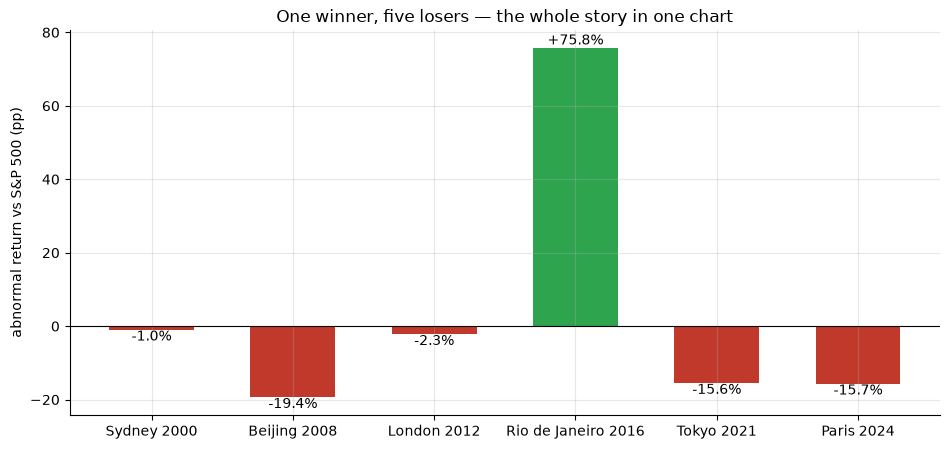

{'Sydney 2000': -1.04, 'Beijing 2008': -19.42, 'London 2012': -2.26, 'Rio de Janeiro 2016': 75.79, 'Tokyo 2021': -15.56, 'Paris 2024': -15.74}


In [2]:
if HAVE_REAL:
    rows = DF.assign(label=DF['city'] + ' ' + DF['year'].astype(str))
    labels, vals = list(rows['label']), list(rows['abn_ret_pct'])
else:
    labels = [f"{h['city']} {h['year']}" for h in R['hosts']]
    vals = [h['abn'] for h in R['hosts']]
fig, ax = plt.subplots(figsize=(9.6, 4.6))
cols = [GREEN if v > 0 else RED for v in vals]
ax.bar(labels, vals, color=cols, width=.6)
for i, v in enumerate(vals):
    ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('abnormal return vs S&P 500 (pp)')
ax.set_title('One winner, five losers — the whole story in one chart')
plt.tight_layout(); plt.show()
print({l: round(v,2) for l,v in zip(labels, vals)})

Five bars point down. One — Rio 2016 — points way, way up. That single bar is doing all the work: it alone is **+75.8 points**, more than four times the size of any other bar. And it has an obvious alternative story: Brazil's stock market was clawing back from the bottom of a brutal commodity-price crash in early 2016 — the Olympics landed in the middle of a recovery that was already underway for reasons that have nothing to do with hosting a sporting event.

**So does the average tell the truth here?**

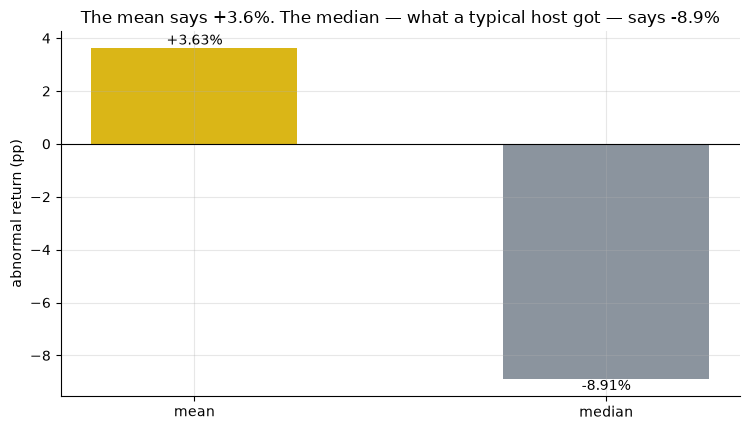

mean +3.63%  median -8.91%


In [3]:
if HAVE_REAL:
    x = DF['abn_ret_pct'].values
    mean_, med_ = float(x.mean()), float(np.median(x))
else:
    mean_, med_ = R['mean'], R['median']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['mean', 'median'], [mean_, med_], color=[AMBER, GREY], width=.5)
for i, v in enumerate([mean_, med_]):
    ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom' if v >= 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('abnormal return (pp)')
ax.set_title('The mean says +3.6%. The median — what a typical host got — says -8.9%')
plt.tight_layout(); plt.show()
print(f'mean {mean_:+.2f}%  median {med_:+.2f}%')

That gap is the whole story in one picture: the **typical** host (the median) actually did about **9 points worse** than the world market around its own Games, and the only reason the mean looks positive is that one country's number is enormous. This is precisely why the desk never stops at a single average on a small sample — a rank test, a bootstrap and a random-date placebo (in the quants notebook) all confirm the same thing: **there's no real pattern here**, just one big outlier with its own explanation.

## 5 · The verdict

- **Signal — None.** Mean **+3.63%** but median **-8.91%** across n = 6 hosts; every statistical test (t, Wilcoxon, bootstrap, placebo) agrees it's noise. Only **1 of 6** hosts actually beat the world market.
- **Tradability — Mirage.** Nothing to trade, and even ignoring that: one event every ~4 years on a different single-country ETF each time is not a repeatable strategy.
- **"Do most hosts actually outperform?" — Busted.** Five of six lost to the world benchmark around their own Games.

## 6 · Going further 🚪

- **The city-level story may differ from the country-level story.** A country ETF dilutes the host CITY's local property/construction boom into a whole national economy — a REIT or a construction-sector index for the host city might show more (or the same nothing).
- **The award-day pop is a different, narrower question.** Some academic work (Berman, Brooks & Davidson) finds a modest positive reaction to the host-city *announcement* itself — years before the Games — which this study doesn't test.
- **Sibling studies:** [234-olympic-year](../../234-olympic-year/) (any Olympic year, US market, not host-specific), [235-world-cup-effect](../../235-world-cup-effect/) (the analogous global-market World Cup test), [708-eurovision-effect](../../708-eurovision-effect/) (the same host-lift question for a smaller event).

*Think a host-city-specific instrument would show something different? Show a net, certifiable edge on real, tradable instruments — then we'll talk.*